In [2]:
# Importing all the required statements
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [3]:
# importing the dataset
data=pd.read_csv("Student.csv")
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


**Exploring the data, Like what it has in the columns, No.of rows, Is their any null values etc.**

In [4]:
data.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

**ie it has 20 different columns which will help us to train the model and to be overcome the overfitting condition**

In [5]:
data.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [7]:
data.isnull().mean()*100

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [8]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [9]:
data["Teacher_Quality"].mode(),data["Parental_Education_Level"].mode(),data["Distance_from_Home"].mode()

(0    Medium
 Name: Teacher_Quality, dtype: object,
 0    High School
 Name: Parental_Education_Level, dtype: object,
 0    Near
 Name: Distance_from_Home, dtype: object)

**Since the columns that have null values i.e, `Teacher_Quality`,`Parental_Eductaion_level`,`Distance_from_Home` all of them are object so the most ifficent way to fill that null values are by using the mode(Most reapeted number)** 

In [10]:
data["Teacher_Quality"]=data["Teacher_Quality"].fillna(data["Teacher_Quality"].mode()[0])

In [11]:
data["Teacher_Quality"].isnull().sum()

np.int64(0)

In [12]:
data["Parental_Education_Level"]=data["Parental_Education_Level"].fillna(data["Parental_Education_Level"].mode()[0])
data["Distance_from_Home"]=data["Distance_from_Home"].fillna(data["Distance_from_Home"].mode()[0])

In [13]:
data.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

**Excellent all the null value in the data have been handled** 

<Axes: xlabel='Hours_Studied', ylabel='Exam_Score'>

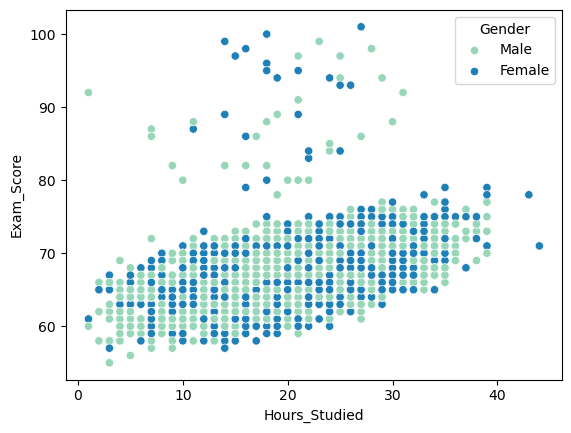

In [14]:
sns.scatterplot(x="Hours_Studied",y="Exam_Score",data=data,hue="Gender",palette="YlGnBu")

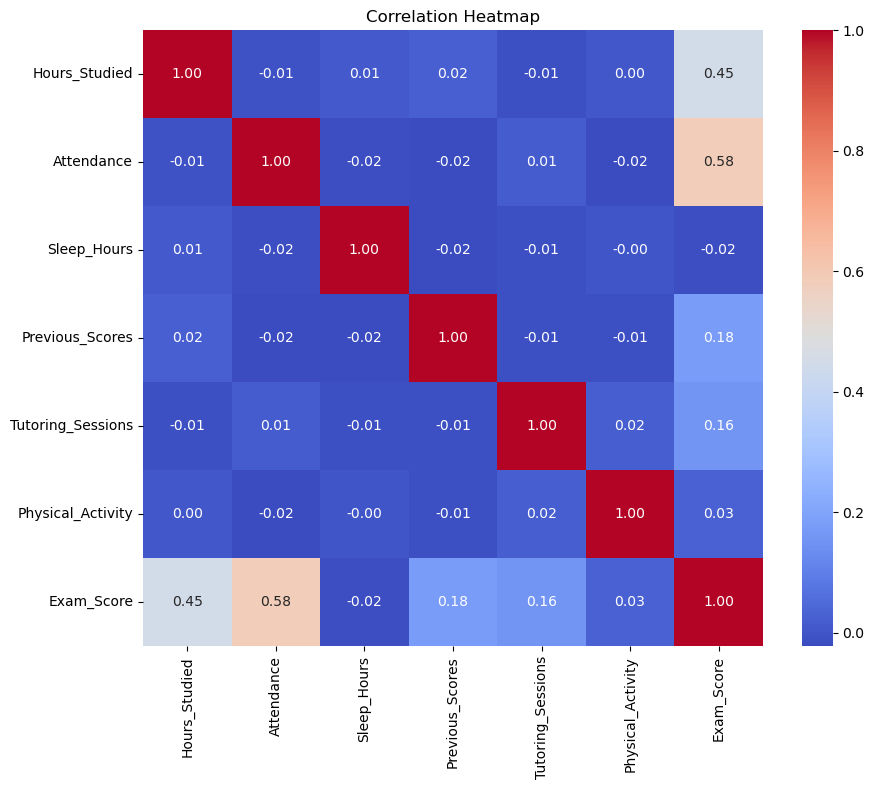

In [15]:
corr_matrix=data.corr(numeric_only=True)       
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

 **Correlation values in very efficent way to view how the data are interelated to eachother ie**
- +1 (Red) shows the strong positive correlation.
- -1 (Blue) shows the strong negative correlation.
- 0 (Light color) little or not correlation.

In [16]:
corr = data.corr(numeric_only=True)

corr["Exam_Score"].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64

**Before passing the argument to train the model lets weight some columns that helps model to predict effectively. Some of the columns are.**
- Parental_Education_Level.
- Teacher_Quality.
- Motivation_Level.

In [17]:
mapping={
    "High School":0,
    "College":1,
    "Postgraduate":2,
}
data["Parental_Education_Level"]=data["Parental_Education_Level"].map(mapping)

In [18]:
data["Teacher_Quality"]

0       Medium
1       Medium
2       Medium
3       Medium
4         High
         ...  
6602    Medium
6603      High
6604    Medium
6605    Medium
6606    Medium
Name: Teacher_Quality, Length: 6607, dtype: object

In [19]:
data["Parental_Education_Level"].value_counts()

Parental_Education_Level
0    3313
1    1989
2    1305
Name: count, dtype: int64

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [21]:
data["Parental_Education_Level"]


0       0
1       1
2       2
3       0
4       1
       ..
6602    0
6603    0
6604    2
6605    0
6606    2
Name: Parental_Education_Level, Length: 6607, dtype: int64

In [22]:
mapping_1={
    "Low":0,
    "Medium":1,
    "High":2
}

data["Teacher_Quality"]=data["Teacher_Quality"].map(mapping_1)
data["Teacher_Quality"]

0       1
1       1
2       1
3       1
4       2
       ..
6602    1
6603    2
6604    1
6605    1
6606    1
Name: Teacher_Quality, Length: 6607, dtype: int64

In [23]:
data["Teacher_Quality"].value_counts()

Teacher_Quality
1    4003
2    1947
0     657
Name: count, dtype: int64

In [24]:
data["Motivation_Level"].value_counts()

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

In [25]:
mapping_2={
    "Low":0,
    "Medium":1,
    "High":2
}

data["Motivation_Level"]=data["Motivation_Level"].map(mapping_2)
data["Motivation_Level"].value_counts()

Motivation_Level
1    3351
0    1937
2    1319
Name: count, dtype: int64

In [26]:
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,0,Yes,0,Low,1,Public,Positive,3,No,0,Near,Male,67
1,19,64,Low,Medium,No,8,59,0,Yes,2,Medium,1,Public,Negative,4,No,1,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,1,Yes,2,Medium,1,Public,Neutral,4,No,2,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,1,Yes,1,Medium,1,Public,Negative,4,No,0,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,1,Yes,3,Medium,2,Public,Neutral,4,No,1,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,1,Yes,1,High,1,Public,Positive,2,No,0,Near,Female,68
6603,23,76,High,Medium,No,8,81,1,Yes,3,Low,2,Public,Positive,2,No,0,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,0,Yes,3,Low,1,Public,Negative,2,No,2,Near,Female,68
6605,10,86,High,High,Yes,6,91,2,Yes,2,Low,1,Private,Positive,3,No,0,Far,Female,68


In [27]:
X=data[["Hours_Studied","Attendance","Sleep_Hours","Previous_Scores","Teacher_Quality","Parental_Education_Level"]]
y=data["Exam_Score"]

In [28]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
x_train

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Teacher_Quality,Parental_Education_Level
5810,27,79,8,63,1,1
1268,16,86,7,94,2,0
414,22,87,8,83,1,1
4745,18,100,10,86,1,0
654,35,78,10,99,1,0
...,...,...,...,...,...,...
3772,15,82,7,93,2,0
5191,20,65,8,97,1,1
5226,17,64,10,63,1,0
5390,16,100,7,82,1,0


In [30]:
x_test

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Teacher_Quality,Parental_Education_Level
743,20,71,7,87,1,0
5551,22,71,7,98,2,0
3442,21,91,6,53,1,2
6571,12,91,8,81,0,0
4204,21,63,8,95,1,0
...,...,...,...,...,...,...
4709,20,78,10,85,2,0
3664,27,90,7,92,1,0
5231,23,72,6,61,1,0
1773,21,76,6,50,1,2


In [31]:
model=LinearRegression()

In [32]:
model.fit(x_train,y_train)

LinearRegression()

In [33]:
y_pred = model.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [36]:
print(y_test[:5])

743     65
5551    65
3442    71
6571    64
4204    66
Name: Exam_Score, dtype: int64


In [37]:
print(y_pred[:5])

[65.60456399 67.20913117 69.22761499 66.42893836 64.64898656]


** # This error occured becuse, I was trying to predict the marks of the student which is an continous number which is an classification problem i.e, we should use `Regression Metrics`**
- Mean Absolute Error (MEA):Which predict how far the model has predicted from the actual values.
- Mean Squared Error (MSE): Its another Regression metric that sharply increases the bigger mistake.
- r2 : It measures how well your regression model explains the variation in the target variable. 

In [38]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [39]:
print("MAE:", mae)
print("MSE:", mse)
print("R² score:",r2)

MAE: 1.304732790983274
MSE: 5.095587176142891
R² score: 0.63950753094078


**Perfect What it shows is that on an avergae the error is off by 1.3 marks. For example if an student gets 65marks model predicted `66.3`**
**Where as R²=0.63 means that it explain about 63% of varaince in the exam scores.**

Text(0, 0.5, 'Residuals (Errors)')

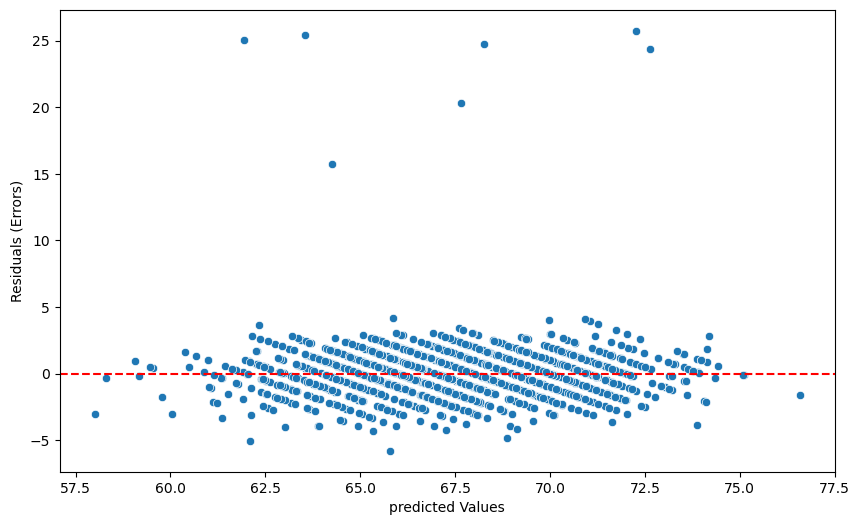

In [44]:
resuidual = y_test-y_pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=resuidual)
plt.axhline(y=0,ls="--",color="r")
plt.xlabel("predicted Values")
plt.ylabel("Residuals (Errors)")

**The reason of getting the MSE=5.095 is because of the about `7` outliers which fall in the range of (15-30). which also indicate that the larger error average around 2.26 marks**

**Further going through all the seven outliers data to see if their is certain kind to pattern why does they got higher marks**

In [41]:
error_df=x_test.copy()
error_df["Actual"]=y_test
error_df["Predict"]=y_pred
error_df["Residual"]=y_test-y_pred

# to filter out the outliers

outliers=error_df[error_df["Residual"]>10]

In [42]:
outliers

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Teacher_Quality,Parental_Education_Level,Actual,Predict,Residual
217,19,70,7,54,1,0,89,63.556992,25.443008
2513,18,86,8,60,2,1,88,67.662543,20.337457
4192,28,90,9,91,1,1,98,72.259154,25.740846
5966,25,99,7,77,2,0,97,72.625611,24.374389
5989,18,61,6,91,2,1,80,64.254582,15.745418
2687,11,71,8,55,1,1,87,61.929583,25.070417
4531,26,69,7,95,1,2,93,68.261488,24.738512


Text(0, 0.5, 'Residuals (Errors)')

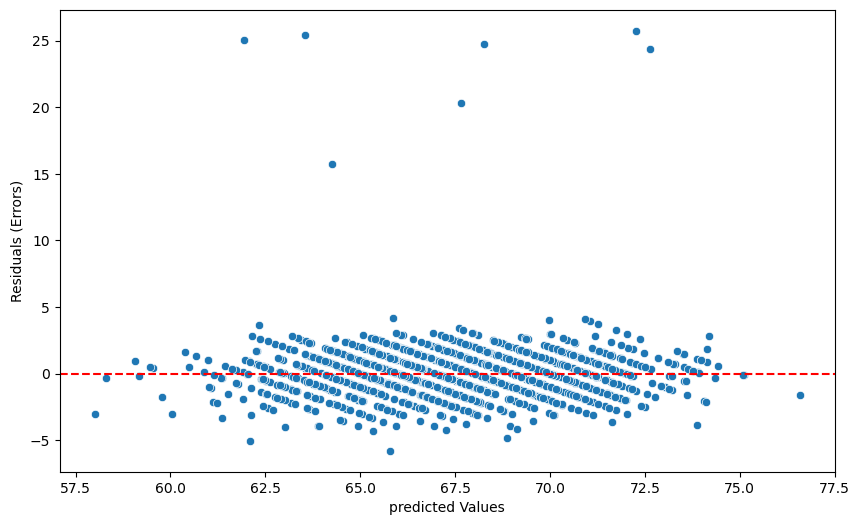

In [43]:
resuidual = y_test-y_pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred, y=resuidual)
plt.axhline(y=0,ls="--",color="r")
plt.xlabel("predicted Values")
plt.ylabel("Residuals (Errors)")

**Since the model is not predicting perfect for the higher marks lets swtich the model to `Decision Tree`. Which will ask the series of the yes/no question to predict the value.**

In [48]:
from sklearn.tree import DecisionTreeRegressor

In [50]:
model_2=DecisionTreeRegressor()